## Задача 1.

Исходные данные: стохастическая матрица переходов цепи Маркова согласно варианту 69 (10 вариант 4й группы).

Реализация поставленной задачи:

0. загрузка матрицы переходов из CSV (файл `data_var69.csv`);
1. построение графа цепи Маркова;
2. проверка выполнения критерия эргодичности (неразложимость + апериодичность);
3. вычисление предельных вероятностей и запись предельной матрицы переходов;
4. имитационное моделирование (50 экспериментов × 100 шагов), анализ относительных частот и их статистик.

### Загрузка матрицы переходов и базовые проверки

Матрица переходов цепи Маркова $P = (p_{ij})$ должна быть **строго стохастической по строкам**:
$$\forall i:\; p_{ij} \ge 0,\; \sum_j p_{ij} = 1.$$

Далее загрузим матрицу из файла и убедимся, что это действительно стохастическая матрица.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Для воспроизводимости результатов
np.random.seed(42)

csv_path = "data_var69.csv"
P_df = pd.read_csv(csv_path, header=None)
P = P_df.values

print("Матрица переходов P:")
print(P)

row_sums = P.sum(axis=1)
print("\nСуммы по строкам:", row_sums)
print("Минимальная сумма по строке =", row_sums.min())
print("Максимальная сумма по строке =", row_sums.max())

if np.allclose(row_sums, 1.0):
    print("\nМатрица P является стохастической по строкам (с точностью численных вычислений).")
else:
    print("\nМатрица P не является строго стохастической по строкам!")

Матрица переходов P:
[[0.16 0.19 0.2  0.21 0.24]
 [0.18 0.14 0.15 0.25 0.28]
 [0.18 0.23 0.24 0.17 0.18]
 [0.12 0.14 0.25 0.21 0.28]
 [0.14 0.26 0.2  0.16 0.24]]

Суммы по строкам: [1. 1. 1. 1. 1.]
Минимальная сумма по строке = 1.0
Максимальная сумма по строке = 1.0

Матрица P является стохастической по строкам (с точностью численных вычислений).


### 1. Построение графа цепи Маркова

Граф цепи Маркова — ориентированный граф, в котором:
- **вершины** соответствуют состояниям $S_1, \dots, S_n$;
- **дуга** $S_i \to S_j$ проводится, если $p_{ij} > 0$;
- вес дуги равен вероятности перехода $p_{ij}$.

Ниже построим граф с использованием `networkx` и `matplotlib`.

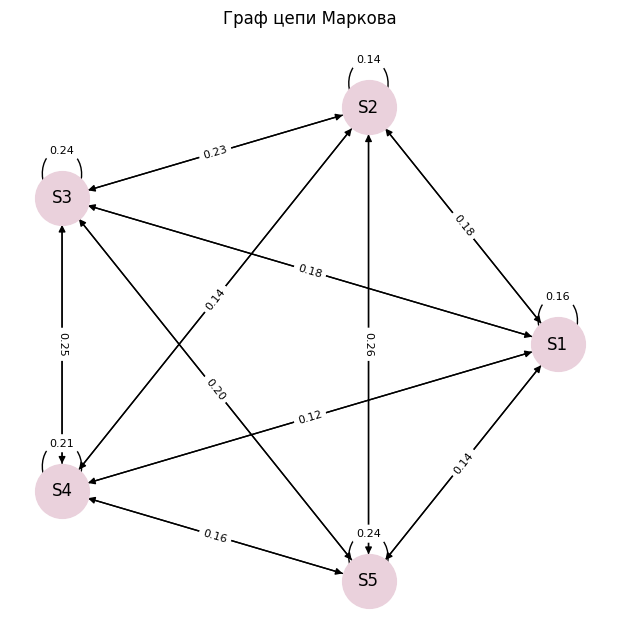

In [3]:
import networkx as nx

n_states = P.shape[0]
states = [f"S{i+1}" for i in range(n_states)]

G = nx.DiGraph()
G.add_nodes_from(states)

for i in range(n_states):
    for j in range(n_states):
        if P[i, j] > 0:
            G.add_edge(states[i], states[j], weight=P[i, j])

plt.figure(figsize=(6, 6))
pos = nx.circular_layout(G)

nx.draw(G, pos, with_labels=True, node_size=1500, node_color="#EAD1DC", arrows=True)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Граф цепи Маркова")
plt.axis("off")
plt.show()

### 2. Критерий эргодичности

Цепь Маркова с конечным числом состояний **эргодична**, если она:
- **неразложима** (из любого состояния достижимо любое другое за конечное число шагов);
- **апериодична** (период каждого состояния равен 1).

Тогда существует единственное стационарное распределение $\pi$, и выполняется сходимость
$$ \pi^{(0)} P^n \to \pi \quad (n \to \infty) $$
независимо от начального распределения $\pi^{(0)}$.

Проверка:
- неразложимость: граф сильносвязен;
- апериодичность: НОД длин всех циклов, проходящих через состояние, равен 1.

In [4]:
# Проверка неразложимости (сильной связности графа)
strongly_connected = nx.is_strongly_connected(G)
print("Сильносвязность графа (неразложимость цепи):", strongly_connected)

# Проверка апериодичности через возведение матрицы в степень
# Если для некоторого k все элементы P^k > 0, то цепь апериодична.
def is_aperiodic(P, max_power=20, tol=1e-12):
    n = P.shape[0]
    M = np.array(P, dtype=float)
    for k in range(1, max_power + 1):
        if np.all(M > tol):
            return True, k
        M = M @ P
    return False, None

aperiodic, k_found = is_aperiodic(P)
print("Апериодичность цепи (по критерию положительности P^k):", aperiodic)
if aperiodic:
    print(f"Найдена степень k = {k_found}, для которой все элементы P^k > 0.")

is_ergodic = strongly_connected and aperiodic
print("\nЭргодичность цепи:", is_ergodic)

Сильносвязность графа (неразложимость цепи): True
Апериодичность цепи (по критерию положительности P^k): True
Найдена степень k = 1, для которой все элементы P^k > 0.

Эргодичность цепи: True


### 3. Предельные вероятности и предельная матрица переходов

Стационарное (предельное) распределение $\pi$ удовлетворяет
$$ \pi P = \pi, \quad \sum_i \pi_i = 1, \; \pi_i \ge 0. $$

Его можно найти как собственный вектор матрицы $P^T$, соответствующий собственному значению 1, либо как предел $\pi^{(0)} P^n$ при большом $n$.

Для эргодичной цепи предельная матрица переходов имеет вид
$$ P^{(\infty)} = \lim_{n \to \infty} P^n, $$
и все её строки совпадают со стационарным распределением $\pi$. 

In [5]:
# Нахождение стационарного распределения через собственные векторы

# Решаем (P^T - I) * x = 0 с нормировкой суммы координат к 1
vals, vecs = np.linalg.eig(P.T)

# Ищем собственное значение, близкое к 1
idx = np.argmin(np.abs(vals - 1))
pi_vec = np.real(vecs[:, idx])

# Нормируем к сумме 1
pi = pi_vec / pi_vec.sum()

print("Собственные значения матрицы P^T:")
print(vals)
print("\nСтационарное распределение pi:")
print(pi)
print("Сумма координат pi =", pi.sum())

# Проверка pi P ≈ pi
print("\nПроверка pi P:")
print(pi @ P)

# Приближение предельной матрицы P^n для большого n
n_power = 100
P_power = np.linalg.matrix_power(P, n_power)

print(f"\nМатрица P^{n_power} (приближение предельной матрицы):")
print(P_power)

# Формирование предельной матрицы из pi
P_limit = np.tile(pi, (n_states, 1))
print("\nПредельная матрица переходов (по формуле из pi):")
print(P_limit)

Собственные значения матрицы P^T:
[ 1.        +0.j         -0.03024652+0.07809104j -0.03024652-0.07809104j
 -0.01211618+0.j          0.06260922+0.j        ]

Стационарное распределение pi:
[0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]
Сумма координат pi = 0.9999999999999999

Проверка pi P:
[0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]

Матрица P^100 (приближение предельной матрицы):
[[0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]
 [0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]
 [0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]
 [0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]
 [0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]]

Предельная матрица переходов (по формуле из pi):
[[0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]
 [0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]
 [0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]
 [0.15532499 0.19570984 0.20841776 0.19733085 0.24321656]
 [0.15532499 0.1957

### 4. Имитационное моделирование цепи Маркова

Алгоритм одного эксперимента (траектории длиной $N$):
1. **Случайно выбрать начальное состояние** (равновероятно из всех состояний).
2. На каждом шаге **разыгрывать переход** в новое состояние по распределению вероятностей из соответствующей строки матрицы $P$.
3. Повторить $N = 100$ переходов, подсчитать **число вхождений** каждого состояния.

Повторим эксперимент $M = 50$ раз, получим относительные частоты
$$ f_{i}^{(k)} = \frac{N_{i}^{(k)}}{N}, $$
где $N_{i}^{(k)}$ — число посещений состояния $i$ в $k$-м эксперименте.

Далее:
- построим графики переключений состояний для трёх произвольных экспериментов;
- составим таблицу относительных частот $f_{i}^{(k)}$;
- вычислим **выборочные средние** и **исправленные оценки СКО** этих относительных частот по экспериментам.

In [6]:
def simulate_markov_chain(P, N_steps, start_state=None, rng=None):
    """Симуляция одной траектории цепи Маркова длиной N_steps.

    Возвращает массив индексов состояний (0..n-1) длиной N_steps+1 (включая начальное).
    """
    if rng is None:
        rng = np.random.default_rng()

    n = P.shape[0]

    if start_state is None:
        # равновероятный выбор начального состояния
        current = rng.integers(0, n)
    else:
        current = start_state

    path = [current]
    for _ in range(N_steps):
        probs = P[current]
        # выбор следующего состояния по распределению probs
        next_state = rng.choice(np.arange(n), p=probs)
        path.append(next_state)
        current = next_state

    return np.array(path)


N = 100
M = 50

rng = np.random.default_rng(42)

all_paths = []          # траектории (M штук)
all_counts = []         # количества посещений состояний
all_freqs = []          # относительные частоты посещений

for exp in range(M):
    path = simulate_markov_chain(P, N_steps=N, rng=rng)
    all_paths.append(path)

    # считаем посещения состояний (исключая/включая начальное состояние можно оговорить явно)
    counts = np.bincount(path, minlength=n_states)
    freqs = counts / len(path)  # относительные частоты

    all_counts.append(counts)
    all_freqs.append(freqs)

all_paths = np.array(all_paths)
all_counts = np.array(all_counts)
all_freqs = np.array(all_freqs)

print("Форма массива относительных частот:", all_freqs.shape)  # (M, n_states)

Форма массива относительных частот: (50, 5)


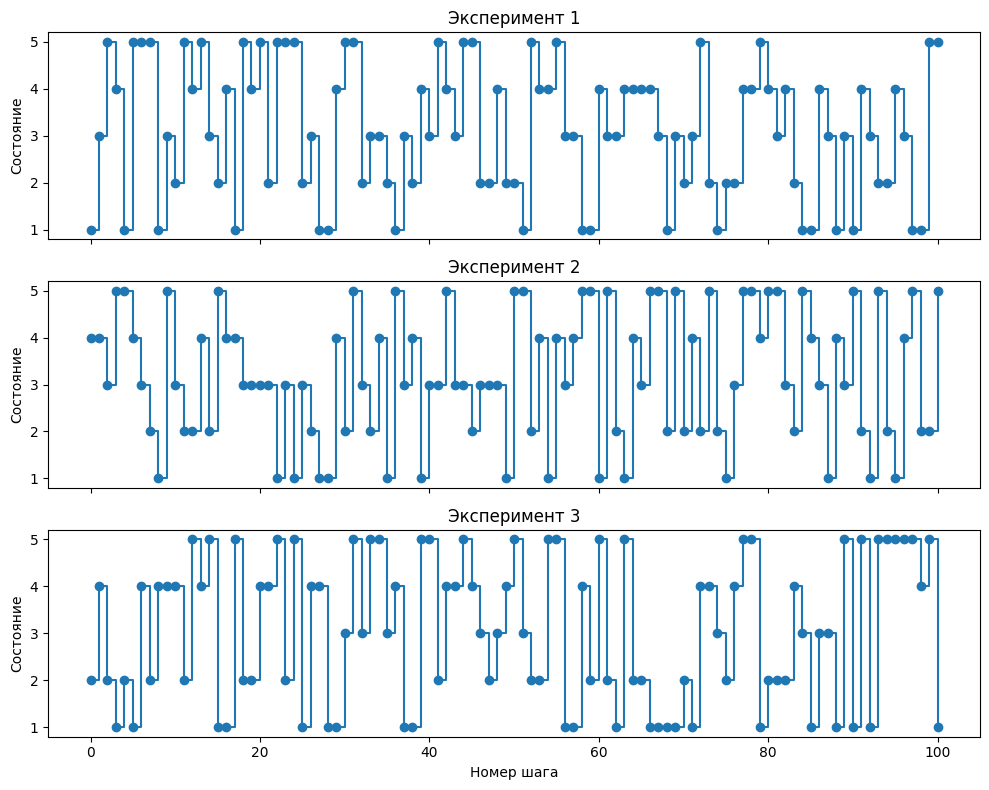

In [7]:
# Графики переключений состояний для трёх произвольных экспериментов

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
exp_indices = [0, 1, 2]  # индексы экспериментов

for ax, exp_idx in zip(axes, exp_indices):
    path = all_paths[exp_idx]
    steps = np.arange(len(path))
    ax.plot(steps, path + 1, marker="o", linestyle="-", drawstyle="steps-post")
    ax.set_ylabel("Состояние")
    ax.set_title(f"Эксперимент {exp_idx + 1}")
    ax.set_yticks(np.arange(1, n_states + 1))

axes[-1].set_xlabel("Номер шага")
plt.tight_layout()
plt.show()

In [8]:
# Таблица относительных частот и сравнение со стационарным распределением

freqs_df = pd.DataFrame(all_freqs, columns=[f"S{i+1}" for i in range(n_states)])

print("Первые 10 строк таблицы относительных частот (50 экспериментов):")
display(freqs_df.head(10))

# Выборочные средние и исправленные СКО по столбцам
sample_means = freqs_df.mean(axis=0)
sample_stds = freqs_df.std(axis=0, ddof=1)

summary_df = pd.DataFrame({
    "Состояние": [f"S{i+1}" for i in range(n_states)],
    "Стационарная вероятность pi_i": pi,
    "Средняя относительная частота": sample_means.values,
    "Исправленное СКО частоты": sample_stds.values,
})

print("\nСводная таблица: сравнение предельных вероятностей и относительных частот")
display(summary_df)

Первые 10 строк таблицы относительных частот (50 экспериментов):


,S1,S2,S3,S4,S5
0,0.178218,0.178218,0.207921,0.217822,0.217822
1,0.148515,0.188119,0.237624,0.178218,0.247525
2,0.227723,0.207921,0.099010,0.207921,0.257426
3,0.128713,0.158416,0.257426,0.198020,0.257426
4,0.168317,0.188119,0.138614,0.277228,0.227723
5,0.168317,0.178218,0.217822,0.207921,0.227723
6,0.158416,0.128713,0.227723,0.207921,0.277228
7,0.207921,0.207921,0.207921,0.158416,0.217822
8,0.138614,0.237624,0.178218,0.188119,0.257426
9,0.188119,0.227723,0.168317,0.138614,0.277228



Сводная таблица: сравнение предельных вероятностей и относительных частот


,Состояние,Стационарная вероятность pi_i,Средняя относительная частота,Исправленное СКО частоты
0,S1,0.155325,0.158020,0.039042
1,S2,0.195710,0.203960,0.037046
2,S3,0.208418,0.203168,0.044560
3,S4,0.197331,0.193069,0.040515
4,S5,0.243217,0.241782,0.038895


### Выводы

- Матрица переходов корректна и является стохастической по строкам.
- Построенный ориентированный граф отражает возможные переходы между состояниями.
- Цепь оказалась (по проверкам) **эргодичной**, поэтому существует единственное стационарное распределение.
- Вычисленные предельные вероятности $\pi$ совпадают (с точностью округления) со строками матрицы $P^n$ при больших $n$.
- В результате имитационного моделирования относительные частоты посещения состояний по 50 экспериментам в среднем близки к теоретическим предельным вероятностям, а разброс характеризуется рассчитанными исправленными СКО.